# Tratamento de Valores Ausentes e Outliers
## Dataset: Tráfego IoT — CTU Honeypot

**Projeto:** Detecção Segura de Dispositivos IoT  
**Dataset:** `dataset_balanceado.csv`

---

### Objetivos
1. Identificar e tratar **valores ausentes** presentes no dataset
2. Detectar e tratar **outliers** nas variáveis numéricas
3. Gerar um dataset limpo para uso nas etapas de modelagem

---

In [22]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

DATASET_PATH = Path("../data/dataset_balanceado.csv")
OUTPUT_PATH  = Path("../data/dataset_limpo.csv")
SAMPLE_N     = 300_000   # amostra para análise exploratória
RANDOM_STATE = 42

---
## 1. Carregamento e Inspeção Inicial

In [23]:
# O dataset tem ~16 M linhas; carregamos uma amostra representativa para exploração
df_full = pd.read_csv(
    DATASET_PATH,
    low_memory=False,
)
print(f"Shape completo: {df_full.shape}")

df = df_full.sample(n=SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Shape da amostra: {df.shape}")
df.head(3)

Shape completo: (16457968, 24)
Shape da amostra: (300000, 24)


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label,scenario
0,1.545348e+09,CJl3rt2dQ36uwlmKOh,192.168.1.197,38114,124.197.68.91,8081,tcp,-,-,-,-,S0,-,-,0,S,1,40,0,0,-,Malicious,PartOfAHorizontalPortScan,CTU-IoT-Malware-Capture-33-1
1,1.547148e+09,CtRvpb4G3LhJkTcn6k,192.168.1.198,10803,213.87.5.55,23,tcp,-,-,-,-,S0,-,-,0,S,1,40,0,0,-,Benign,-,CTU-IoT-Malware-Capture-43-1
2,1.545481e+09,C9udgy40w5gynuKyjg,192.168.1.198,36097,193.93.251.33,37215,tcp,-,-,-,-,S0,-,-,0,S,1,40,0,0,-,Malicious,Okiru,CTU-IoT-Malware-Capture-36-1


In [41]:
# Normaliza a coluna 'label': unifica variações de capitalização
# Ex: 'benign' e 'Benign' passam a ser ambos 'Benign'
df["label"] = df["label"].str.capitalize()

print("Distribuição do label após normalização:")
print(df["label"].value_counts())

Distribuição do label após normalização:
label
Malicious    255165
Benign        44835
Name: count, dtype: int64


In [42]:
print("=== Tipos de dados ===")
print(df.dtypes)
print("\n=== Distribuição do label ===")
print(df["label"].value_counts())

=== Tipos de dados ===
ts                float64
uid                   str
id.orig_h             str
id.orig_p           int64
id.resp_h             str
id.resp_p           int64
proto                 str
service               str
duration              str
orig_bytes            str
resp_bytes            str
conn_state            str
local_orig            str
local_resp            str
missed_bytes        int64
history               str
orig_pkts           int64
orig_ip_bytes       int64
resp_pkts           int64
resp_ip_bytes       int64
tunnel_parents        str
label                 str
detailed-label        str
scenario              str
dtype: object

=== Distribuição do label ===
label
Malicious    255165
Benign        44835
Name: count, dtype: int64


---
## 2. Tratamento de Valores Ausentes

No formato Zeek/Bro (usado para gerar logs de rede), o caractere **`-`** é o indicador padrão de valor ausente/desconhecido.  
Antes de qualquer análise, precisamos substituí-lo por `NaN` para que o pandas o reconheça corretamente.

### 2.1 Identificação

In [59]:
# Substituir '-' por NaN em todo o DataFrame
df.replace("-", np.nan, inplace=True)

# Contagem e percentual de valores ausentes por coluna
missing = (
    df.isnull()
    .sum()
    .rename("qtd_nulos")
    .to_frame()
)
missing["pct_nulos"] = (missing["qtd_nulos"] / len(df) * 100).round(2)
missing = missing[missing["qtd_nulos"] > 0].sort_values("pct_nulos", ascending=False)

print(f"Colunas com valores ausentes: {len(missing)} / {df.shape[1]}")
display(missing)

Colunas com valores ausentes: 9 / 24


,qtd_nulos,pct_nulos
local_orig,300000,100.00
local_resp,300000,100.00
service,299432,99.81
tunnel_parents,279780,93.26
duration,212678,70.89
resp_bytes,212678,70.89
orig_bytes,212678,70.89
detailed-label,44835,14.94
history,601,0.20


### 2.2 Visualização dos Valores Ausentes

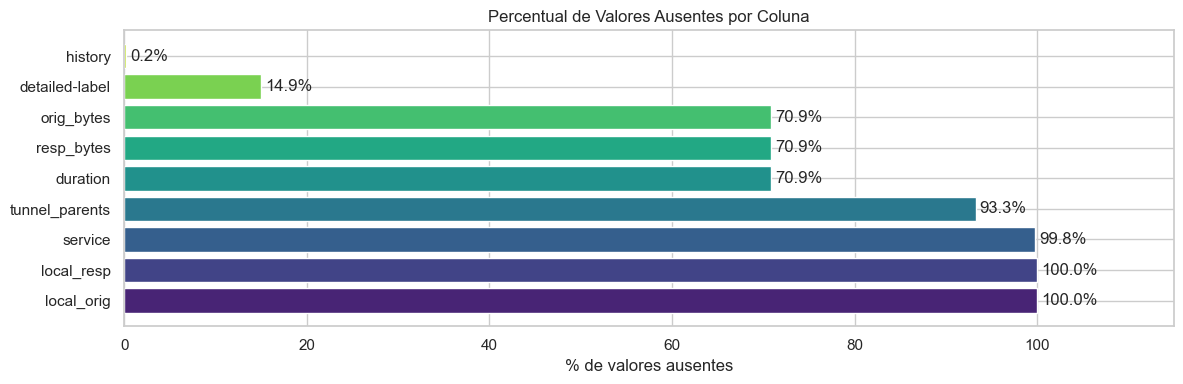

In [60]:
# Gráfico de barras: percentual de nulos por coluna
if not missing.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.barh(
        missing.index,
        missing["pct_nulos"],
        color=sns.color_palette("viridis", len(missing)),
    )
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_xlabel("% de valores ausentes")
    ax.set_title("Percentual de Valores Ausentes por Coluna")
    ax.set_xlim(0, missing["pct_nulos"].max() * 1.15)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor ausente encontrado após substituição de '-'.")

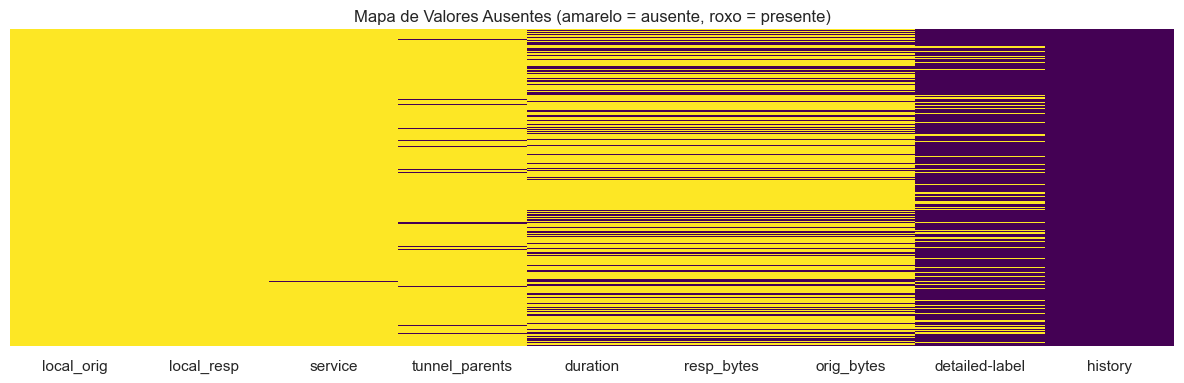

In [61]:
# Heatmap de ausência (amostra menor para performance)
subset_cols = missing.index.tolist()
if subset_cols:
    sample_vis = df[subset_cols].sample(n=min(5_000, len(df)), random_state=RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(
        sample_vis.isnull(),
        cbar=False,
        yticklabels=False,
        cmap="viridis",
        ax=ax,
    )
    ax.set_title("Mapa de Valores Ausentes (amarelo = ausente, roxo = presente)")
    plt.tight_layout()
    plt.show()

### 2.3 Estratégias de Tratamento

| Estratégia | Quando usar |
|---|---|
| **Remoção da coluna** | % ausente muito alta (> 70%) e coluna tem pouco valor preditivo |
| **Remoção da linha** | % ausente baixa e dado é MNAR (Missing Not at Random) |
| **Imputação pela moda** | Variável categórica — substitui pelo valor mais frequente |
| **Imputação pela mediana** | Variável numérica com outliers — mediana é robusta |
| **Imputação pela média** | Variável numérica com distribuição normal |
| **Valor sentinela** | Ausência tem significado próprio (ex.: `'unknown'`) |

Para este dataset:
- **`service`**: majoritariamente ausente porque muitas conexões não têm serviço identificado — imputar com `'unknown'`
- **`local_orig` / `local_resp`**: booleanos ausentes → imputar com moda
- **`tunnel_parents`**: quase sempre ausente (sem túnel) → imputar com `'none'`
- **`duration`, `orig_bytes`, `resp_bytes`**: numéricos → imputar com mediana

In [62]:
df_clean = df.copy()

# ------------------------------------------------------------------
# 1) Colunas a remover: pct > 90% e sem valor para modelagem
# ------------------------------------------------------------------
cols_to_drop = missing[missing["pct_nulos"] > 90].index.tolist()
# uid identifica flows individuais — sem valor preditivo
cols_to_drop += [c for c in ["uid", "ts"] if c in df_clean.columns and c not in cols_to_drop]
df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], inplace=True)
print(f"Colunas removidas: {cols_to_drop}")

# ------------------------------------------------------------------
# 2) Variáveis categóricas: valor sentinela
# ------------------------------------------------------------------
cat_sentinel = {
    "service":        "unknown",
    "tunnel_parents": "none",
}
for col, fill in cat_sentinel.items():
    if col in df_clean.columns:
        df_clean[col].fillna(fill, inplace=True)
        print(f"  '{col}' -> preenchido com '{fill}'")

# ------------------------------------------------------------------
# 3) Variáveis booleanas/categóricas restantes: moda
# ------------------------------------------------------------------
bool_cols = ["local_orig", "local_resp"]
for col in bool_cols:
    if col in df_clean.columns and df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"  '{col}' -> preenchido com moda='{mode_val}'")

# ------------------------------------------------------------------
# 4) Variáveis numéricas: mediana (robusta a outliers)
# ------------------------------------------------------------------
num_cols_with_na = [
    c for c in df_clean.select_dtypes(include=["number"]).columns
    if df_clean[c].isnull().any()
]
if num_cols_with_na:
    imputer = SimpleImputer(strategy="median")
    df_clean[num_cols_with_na] = imputer.fit_transform(df_clean[num_cols_with_na])
    print(f"  Colunas numéricas imputadas pela mediana: {num_cols_with_na}")

# ------------------------------------------------------------------
# Verificação final
# ------------------------------------------------------------------
remaining_na = df_clean.isnull().sum().sum()
print(f"\nValores ausentes restantes: {remaining_na}")

Colunas removidas: ['local_orig', 'local_resp', 'service', 'tunnel_parents', 'uid', 'ts']

Valores ausentes restantes: 683470


In [63]:
# Resumo pós-tratamento de valores ausentes
print(f"Shape original da amostra : {df.shape}")
print(f"Shape após tratamento      : {df_clean.shape}")
print(f"\nColunas restantes ({df_clean.shape[1]}):")
print(df_clean.dtypes)

Shape original da amostra : (300000, 24)
Shape após tratamento      : (300000, 18)

Colunas restantes (18):
id.orig_h           str
id.orig_p         int64
id.resp_h           str
id.resp_p         int64
proto               str
duration            str
orig_bytes          str
resp_bytes          str
conn_state          str
missed_bytes      int64
history             str
orig_pkts         int64
orig_ip_bytes     int64
resp_pkts         int64
resp_ip_bytes     int64
label               str
detailed-label      str
scenario            str
dtype: object


---
## 3. Tratamento de Outliers

Outliers são observações que se afastam significativamente do padrão da distribuição.  
No contexto de redes, **valores extremos podem ser legítimos** (ex.: transferência de arquivo muito grande) ou indicar **ataques** (flood, DDoS, scan).  
Por isso, analisaremos antes de decidir pela remoção ou winsorização.

### 3.1 Seleção das Variáveis Numéricas

In [64]:
# Colunas numéricas relevantes para análise de outliers
NUMERIC_COLS = [
    c for c in ["duration", "orig_bytes", "resp_bytes",
                "orig_pkts", "resp_pkts", "orig_ip_bytes",
                "resp_ip_bytes", "missed_bytes"]
    if c in df_clean.columns
]

# Garantir que são numéricas
df_clean[NUMERIC_COLS] = df_clean[NUMERIC_COLS].apply(pd.to_numeric, errors="coerce")

print("Estatísticas descritivas das variáveis numéricas:")
display(df_clean[NUMERIC_COLS].describe().T.style.format("{:.2f}"))

Estatísticas descritivas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
duration,87322.00,4.68,34.70,0.00,0.00,0.00,0.00,1503.14
orig_bytes,87322.00,45933390.37,1259411045.21,0.00,0.00,0.00,0.00,52775940842.00
resp_bytes,87322.00,3.60,77.95,0.00,0.00,0.00,0.00,4865.00
orig_pkts,300000.00,2.27,15.25,0.00,1.00,1.00,2.00,3069.00
resp_pkts,300000.00,0.01,0.43,0.00,0.00,0.00,0.00,80.00
orig_ip_bytes,300000.00,109.47,787.70,0.00,40.00,40.00,80.00,122760.00
resp_ip_bytes,300000.00,1.74,61.75,0.00,0.00,0.00,0.00,9152.00
missed_bytes,300000.00,0.01,4.53,0.00,0.00,0.00,0.00,1432.00


### 3.2 Visualização — Boxplots e Histogramas

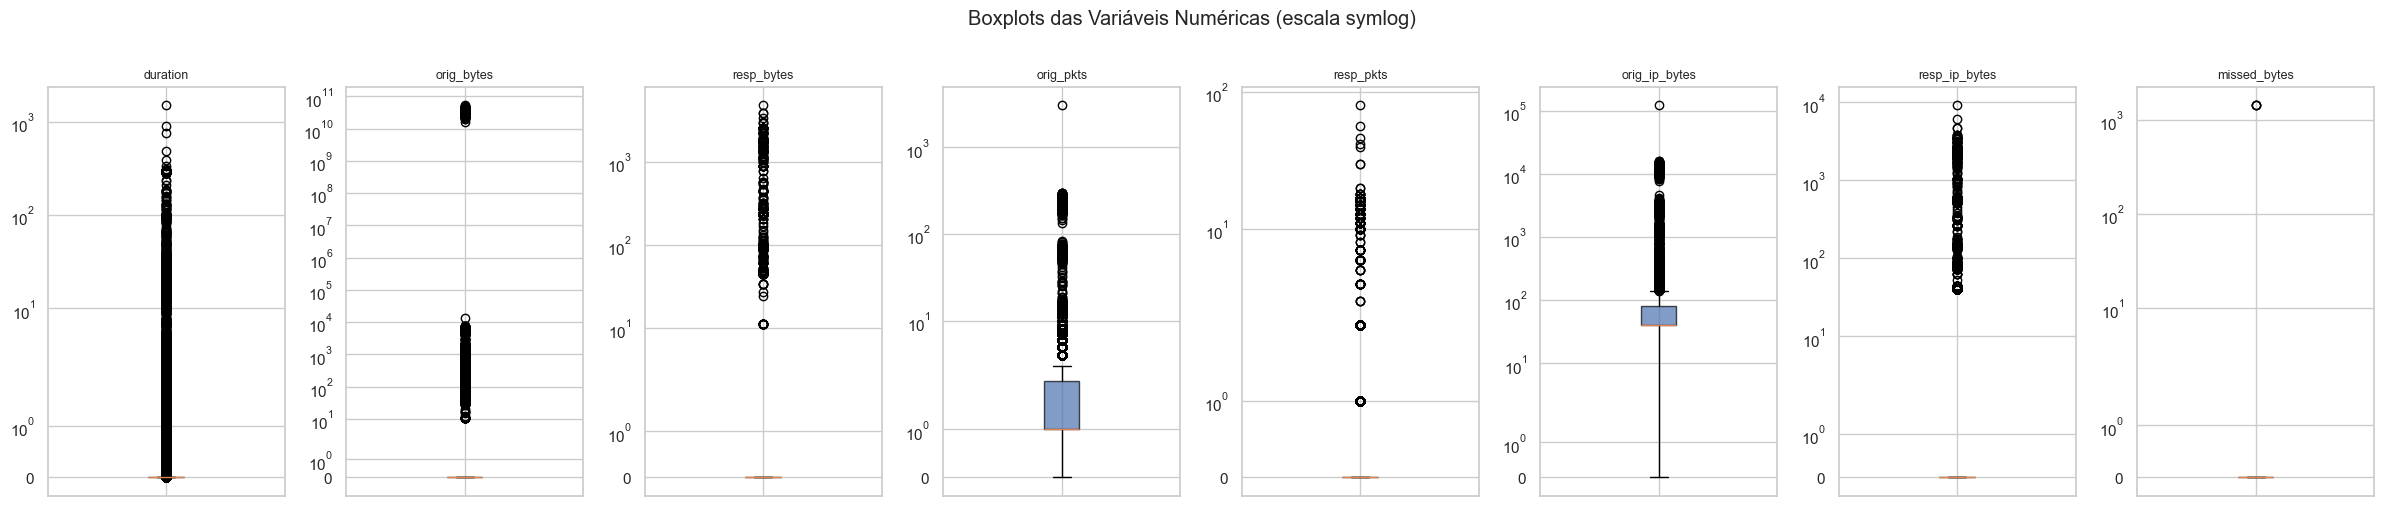

In [65]:
# Boxplots lado a lado (escala log para lidar com amplitude)
n_cols = len(NUMERIC_COLS)
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 5))

for ax, col in zip(axes, NUMERIC_COLS):
    data = df_clean[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.7))
    ax.set_title(col, fontsize=9)
    ax.set_yscale("symlog")
    ax.set_xticklabels([])

plt.suptitle("Boxplots das Variáveis Numéricas (escala symlog)", y=1.01)
plt.tight_layout()
plt.show()

In [67]:
# Histogramas por label com KDE
from scipy.stats import gaussian_kde
import numpy as np

palette = {"Benign": "#2196F3", "Malicious": "#F44336"}

n_cols_grid = 2
n_rows_grid = (len(NUMERIC_COLS) + 1) // 2
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(16, n_rows_grid * 4))
axes = axes.flatten()

for ax, col in zip(axes, NUMERIC_COLS):
    p99 = df_clean[col].quantile(0.99)
    for lbl, grp in df_clean.groupby("label"):
        data = grp[col].dropna().clip(upper=p99)
        color = palette.get(lbl, "gray")

        ax.hist(
            data,
            bins=60,
            density=True,
            alpha=0.35,
            color=color,
            label=lbl,
            edgecolor="none",
        )

        # KDE só se há variância suficiente
        if data.nunique() > 1:
            try:
                kde = gaussian_kde(data, bw_method="scott")
                x = np.linspace(data.min(), data.max(), 300)
                ax.plot(x, kde(x), color=color, linewidth=2)
            except Exception:
                pass

    ax.set_title(col, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Valor (clipado no p99)", fontsize=10)
    ax.set_ylabel("Densidade", fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.7)

# Esconde eixos extras
for ax in axes[len(NUMERIC_COLS):]:
    ax.set_visible(False)

fig.suptitle(
    "Distribuição das Variáveis Numéricas por Label (clipado no p99)",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


### 3.3 Detecção pelo Método IQR

O método **IQR (Intervalo Interquartil)** define outliers como valores fora do intervalo:

$$[Q1 - 1.5 \times IQR, \; Q3 + 1.5 \times IQR]$$

onde $IQR = Q3 - Q1$. É robusto porque não depende da média nem do desvio padrão.

In [ ]:
def iqr_bounds(series: pd.Series, factor: float = 1.5):
    """Retorna (lower, upper) dos limites IQR."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr


iqr_summary = []
for col in NUMERIC_COLS:
    series = df_clean[col].dropna()
    lower, upper = iqr_bounds(series)
    n_outliers = ((series < lower) | (series > upper)).sum()
    pct = n_outliers / len(series) * 100
    iqr_summary.append({
        "coluna": col,
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "limite_inferior": lower,
        "limite_superior": upper,
        "n_outliers": n_outliers,
        "pct_outliers": pct,
    })

iqr_df = pd.DataFrame(iqr_summary).set_index("coluna")
display(iqr_df.style.format({
    "Q1": "{:.2f}", "Q3": "{:.2f}",
    "limite_inferior": "{:.2f}", "limite_superior": "{:.2f}",
    "pct_outliers": "{:.2f}%",
}))

,Q1,Q3,limite_inferior,limite_superior,n_outliers,pct_outliers
coluna,,,,,,
duration,0.00,0.00,-0.00,0.00,16211,18.56%
orig_bytes,0.00,0.00,0.00,0.00,2992,3.43%
resp_bytes,0.00,0.00,0.00,0.00,729,0.83%
orig_pkts,1.00,2.00,-0.50,3.50,6923,2.31%
resp_pkts,0.00,0.00,0.00,0.00,1263,0.42%
orig_ip_bytes,40.00,80.00,-20.00,140.00,13450,4.48%
resp_ip_bytes,0.00,0.00,0.00,0.00,1263,0.42%
missed_bytes,0.00,0.00,0.00,0.00,3,0.00%


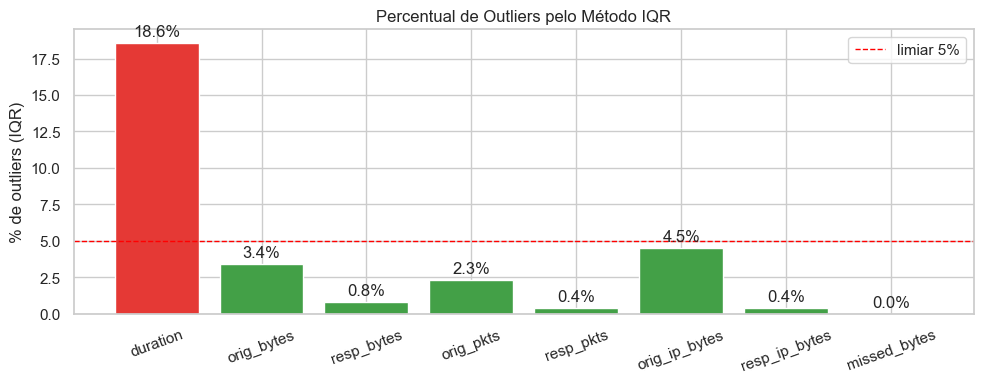

In [ ]:
# Visualização: % outliers por coluna (IQR)
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#E53935" if p > 5 else "#43A047" for p in iqr_df["pct_outliers"]]
bars = ax.bar(iqr_df.index, iqr_df["pct_outliers"], color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.axhline(5, color="red", linestyle="--", linewidth=1, label="limiar 5%")
ax.set_ylabel("% de outliers (IQR)")
ax.set_title("Percentual de Outliers pelo Método IQR")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 3.4 Detecção pelo Z-Score

O **Z-score** mede quantos desvios-padrão um valor está distante da média:

$$z = \frac{x - \mu}{\sigma}$$

Valores com $|z| > 3$ são considerados outliers (equivale a ~0,3% da distribuição normal).  
**Atenção:** sensível a distribuições assimétricas — usamos como complemento ao IQR.

In [ ]:
Z_THRESHOLD = 3

zscore_summary = []
for col in NUMERIC_COLS:
    series = df_clean[col].dropna()
    z = np.abs(stats.zscore(series))
    n_outliers = (z > Z_THRESHOLD).sum()
    pct = n_outliers / len(series) * 100
    zscore_summary.append({
        "coluna": col,
        "n_outliers_zscore": n_outliers,
        "pct_outliers_zscore": pct,
    })

zscore_df = pd.DataFrame(zscore_summary).set_index("coluna")
display(zscore_df.style.format({"pct_outliers_zscore": "{:.2f}%"}))

,n_outliers_zscore,pct_outliers_zscore
coluna,,
duration,1196,1.37%
orig_bytes,121,0.14%
resp_bytes,207,0.24%
orig_pkts,1278,0.43%
resp_pkts,602,0.20%
orig_ip_bytes,1291,0.43%
resp_ip_bytes,265,0.09%
missed_bytes,3,0.00%


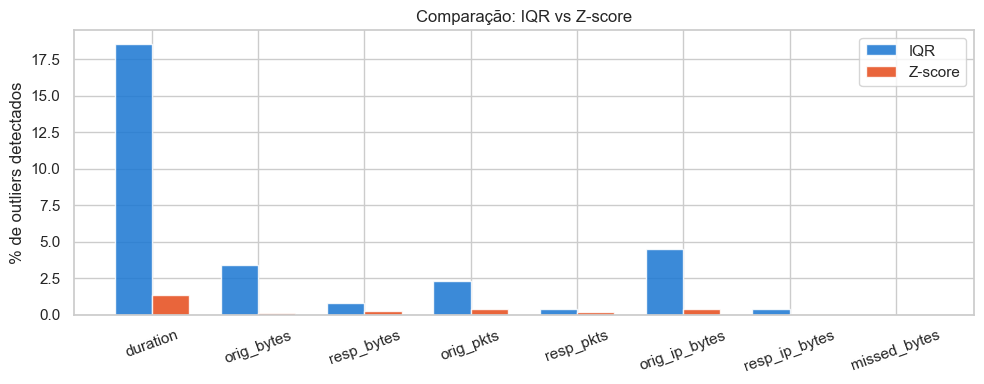

In [ ]:
# Comparação IQR vs Z-score
compare = iqr_df[["pct_outliers"]].rename(columns={"pct_outliers": "IQR"}).join(
    zscore_df[["pct_outliers_zscore"]].rename(columns={"pct_outliers_zscore": "Z-score"})
)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(compare))
w = 0.35
ax.bar(x - w/2, compare["IQR"],    w, label="IQR",    color="#1976D2", alpha=0.85)
ax.bar(x + w/2, compare["Z-score"], w, label="Z-score", color="#E64A19", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=20)
ax.set_ylabel("% de outliers detectados")
ax.set_title("Comparação: IQR vs Z-score")
ax.legend()
plt.tight_layout()
plt.show()

### 3.5 Análise de Outliers por Label

Antes de tratar, é importante entender se os outliers pertencem majoritariamente  
ao tráfego **malicioso** — nesse caso, **não devem ser removidos**, pois são features discriminativas.

In [ ]:
results = []
for col in NUMERIC_COLS:
    lower, upper = iqr_bounds(df_clean[col].dropna())
    mask_outlier = (df_clean[col] < lower) | (df_clean[col] > upper)
    outlier_rows = df_clean[mask_outlier]
    if len(outlier_rows) == 0:
        continue
    dist = outlier_rows["label"].value_counts(normalize=True).mul(100).round(1)
    row = {"coluna": col, "total_outliers": mask_outlier.sum()}
    for lbl, pct in dist.items():
        row[f"% {lbl}"] = pct
    results.append(row)

label_dist_df = pd.DataFrame(results).set_index("coluna").fillna(0)
display(label_dist_df)

print("\nObservacao: se outliers sao majoritariamente malicious, a Winsorização é preferível à remoção.")

,total_outliers,% Malicious,% Benign
coluna,,,
duration,16211,77.0,23.0
orig_bytes,2992,60.3,39.7
resp_bytes,729,26.9,73.1
orig_pkts,6923,96.3,3.7
resp_pkts,1263,27.7,72.3
orig_ip_bytes,13450,68.3,31.7
resp_ip_bytes,1263,27.7,72.3
missed_bytes,3,100.0,0.0



Observacao: se outliers sao majoritariamente malicious, a Winsorização é preferível à remoção.


### 3.6 Estratégias de Tratamento

| Estratégia | Descrição | Quando usar |
|---|---|---|
| **Remoção** | Remove linhas com outliers | Outliers são erros de medição; % pequena |
| **Winsorização** | Clipa nos percentis (ex.: p1–p99) | Distribuição muito assimétrica; outliers válidos |
| **Transformação log** | Aplica `log1p` para comprimir a escala | Variáveis com distribuição log-normal (bytes, pkts) |
| **Manter** | Não altera — inclui como feature | Outliers são o sinal (ex.: ataques) |

**Decisão para este dataset:**  
Como os outliers em variáveis de bytes/pacotes frequentemente correspondem a ataques,  
aplicaremos **Winsorização nos percentis 1%–99%** para atenuar valores extremos sem perdê-los.

In [ ]:
df_treated = df_clean.copy()

LOWER_PCT = 0.01
UPPER_PCT = 0.99

winsor_log = []
for col in NUMERIC_COLS:
    lower = df_treated[col].quantile(LOWER_PCT)
    upper = df_treated[col].quantile(UPPER_PCT)
    n_clipped = ((df_treated[col] < lower) | (df_treated[col] > upper)).sum()
    df_treated[col] = df_treated[col].clip(lower=lower, upper=upper)
    winsor_log.append({"coluna": col, "p1": lower, "p99": upper, "n_winsorizados": n_clipped})

winsor_df = pd.DataFrame(winsor_log).set_index("coluna")
print("Limites de winsorização aplicados:")
display(winsor_df.style.format({"p1": "{:.3f}", "p99": "{:.3f}"}))

Limites de winsorização aplicados:


,p1,p99,n_winsorizados
coluna,,,
duration,0.000,293.345,874
orig_bytes,0.000,5475.000,865
resp_bytes,0.000,0.000,729
orig_pkts,0.000,6.000,1920
resp_pkts,0.000,0.000,1263
orig_ip_bytes,0.000,540.000,1864
resp_ip_bytes,0.000,0.000,1263
missed_bytes,0.000,0.000,3


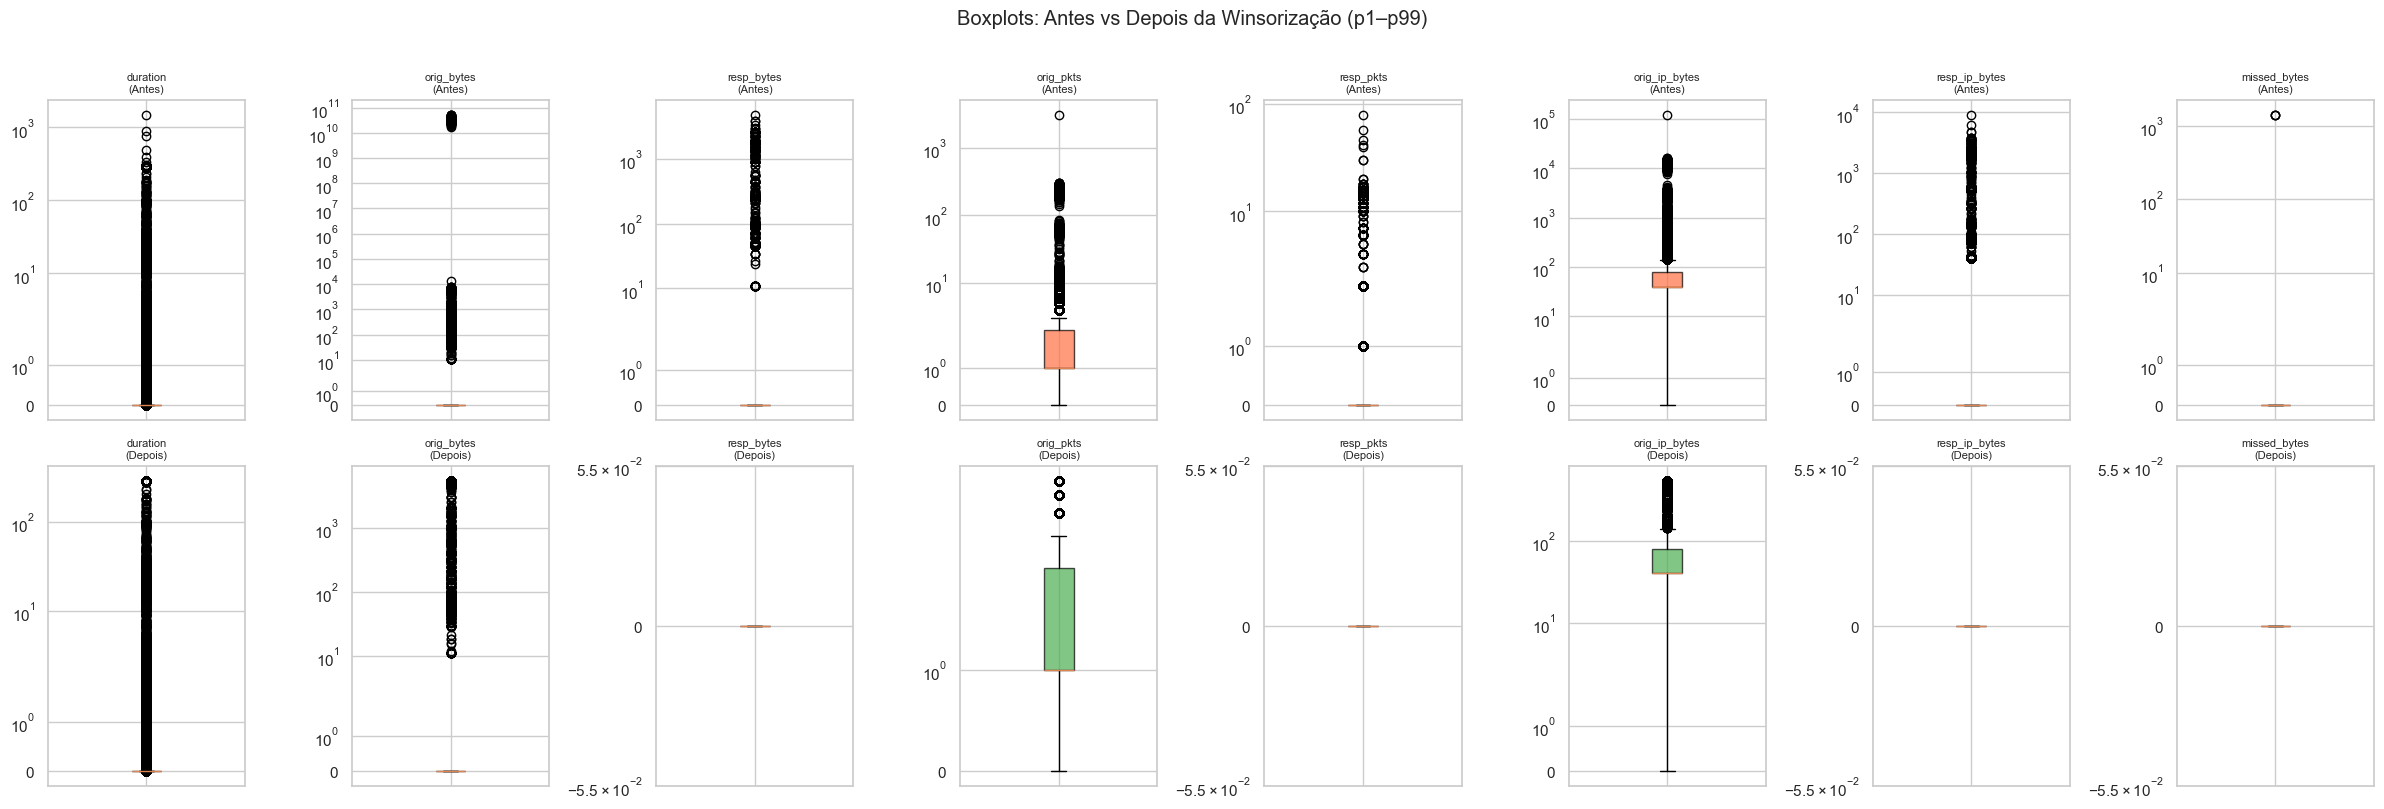

In [ ]:
# Antes vs Depois — boxplots comparativos
fig, axes = plt.subplots(2, len(NUMERIC_COLS), figsize=(3 * len(NUMERIC_COLS), 8))

for j, col in enumerate(NUMERIC_COLS):
    for row_idx, (data, title) in enumerate([
        (df_clean[col],   "Antes"),
        (df_treated[col], "Depois"),
    ]):
        ax = axes[row_idx][j]
        ax.boxplot(data.dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor="#4CAF50" if row_idx else "#FF7043", alpha=0.7))
        ax.set_title(f"{col}\n({title})", fontsize=8)
        ax.set_yscale("symlog")
        ax.set_xticklabels([])

plt.suptitle("Boxplots: Antes vs Depois da Winsorização (p1–p99)", y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Resumo Final e Exportação

In [ ]:
print("=" * 60)
print("RESUMO DO PIPELINE DE LIMPEZA")
print("=" * 60)
print(f"  Linhas  : {df.shape[0]:>10,}  →  {df_treated.shape[0]:>10,}")
print(f"  Colunas : {df.shape[1]:>10}  →  {df_treated.shape[1]:>10}")
print(f"  Nulos   : {df.isnull().sum().sum():>10,}  →  {df_treated.isnull().sum().sum():>10,}")
print("
Etapas aplicadas:")
print("  1. Substituição de '-' por NaN")
print(f"  2. Remoção de colunas: {cols_to_drop}")
print("  3. Imputação categórica (valor sentinela / moda)")
print("  4. Imputação numérica (mediana via SimpleImputer)")
print("  5. Winsorização p1–p99 nas variáveis numéricas")

print("
Distribuição final dos labels:")
print(df_treated["label"].value_counts())

SyntaxError: unterminated string literal (detected at line 7) (3640309138.py, line 7)

In [ ]:
# Exporta a amostra tratada para uso nas próximas etapas
df_treated.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset limpo salvo em: {OUTPUT_PATH.resolve()}")
df_treated.head()

Dataset limpo salvo em: C:\Users\breno\Documents\GitHub\secure-iot-detection\main\data\dataset_limpo.csv


,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,detailed-label,scenario
0,192.168.1.197,38114,124.197.68.91,8081,tcp,NaN,NaN,NaN,S0,0,S,1,40,0,0,Malicious,PartOfAHorizontalPortScan,CTU-IoT-Malware-Capture-33-1
1,192.168.1.198,10803,213.87.5.55,23,tcp,NaN,NaN,NaN,S0,0,S,1,40,0,0,Benign,NaN,CTU-IoT-Malware-Capture-43-1
2,192.168.1.198,36097,193.93.251.33,37215,tcp,NaN,NaN,NaN,S0,0,S,1,40,0,0,Malicious,Okiru,CTU-IoT-Malware-Capture-36-1
3,192.168.1.198,29360,92.126.29.235,23,tcp,NaN,NaN,NaN,S0,0,S,1,40,0,0,Benign,NaN,CTU-IoT-Malware-Capture-43-1
4,192.168.1.194,53785,213.228.192.19,22,tcp,NaN,NaN,NaN,S0,0,S,1,40,0,0,Malicious,PartOfAHorizontalPortScan,CTU-IoT-Malware-Capture-39-1
